# 02 - Distributions, MLE & MAP ⭐

**The single highest-interview-yield notebook in the Statistics chapter.** MLE vs. MAP, and the connection between MAP and regularization, is one of the most-asked "explain the theory behind X" questions in ML interviews.

**Book reference:** *Mathematics for Machine Learning* (Deisenroth, Faisal, Ong) — §6.5, pp.197–205 (Gaussian Distribution) and §8.3, pp.265–272 (Parameter Estimation: MLE and MAP)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## Why the Gaussian is everywhere: the Central Limit Theorem

The Central Limit Theorem (CLT) says: the sum (or average) of many independent random variables trends toward a Gaussian distribution as the count grows — **regardless of the shape of the original distribution**, as long as it has finite variance. Watch this happen starting from something about as un-Gaussian as it gets: a flat Uniform(0,1) distribution.

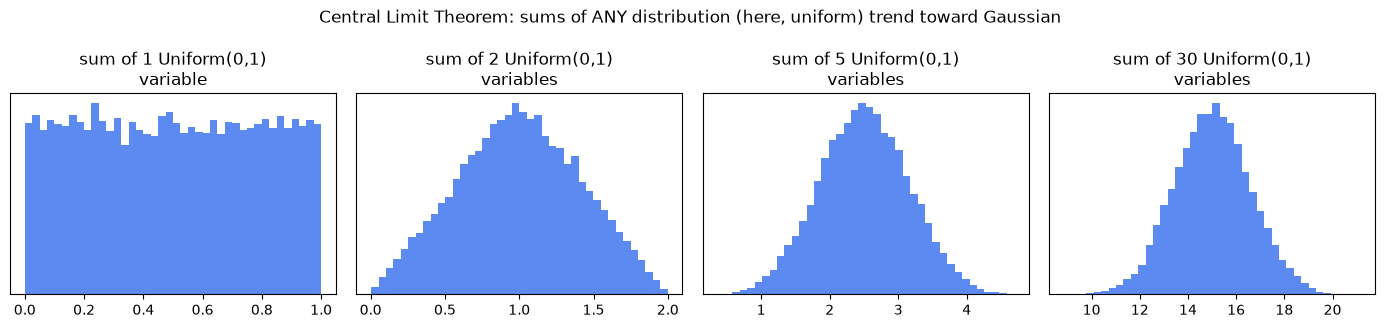

In [2]:
def visualize_clt(savepath: Path = None, rng=None):
    rng = rng or np.random.default_rng(5)
    ns = [1, 2, 5, 30]
    n_trials = 20000
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.3))
    for ax, n in zip(axes, ns):
        samples = rng.uniform(0, 1, size=(n_trials, n)).sum(axis=1)
        ax.hist(samples, bins=40, color="#2563eb", alpha=0.75, density=True)
        ax.set_title(f"sum of {n} Uniform(0,1)\nvariable{'s' if n>1 else ''}")
        ax.set_yticks([])
    fig.suptitle("Central Limit Theorem: sums of ANY distribution (here, uniform) trend toward Gaussian")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_clt(FIG_DIR / "clt_demo.png")

By the time you're summing 30 uniform variables, the result is visually indistinguishable from a bell curve. This is *why* the Gaussian shows up as a default modeling assumption across statistics and ML — measurement noise, aggregated user behavior, sums of many small independent effects — so much of what we measure is itself a sum of many small factors, and the CLT says that sum looks Gaussian almost regardless of the details.

## Maximum Likelihood Estimation

MLE asks: **given the data I observed, which parameter values make that data most probable?** For a Gaussian, this has a clean closed form — the MLE mean is just the sample mean, and the MLE variance is the sample variance (with `1/n`, not `1/(n-1)`).

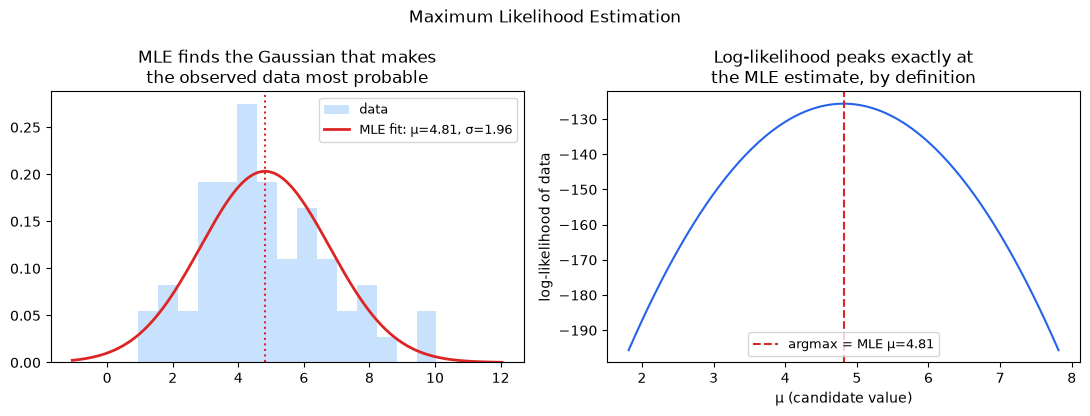

MLE estimates: mu=4.815, sigma=1.963 (true values were 5.0, 2.0)


In [3]:
def visualize_mle_gaussian(savepath: Path = None, rng=None):
    rng = rng or np.random.default_rng(9)
    true_mu, true_sigma = 5.0, 2.0
    data = rng.normal(true_mu, true_sigma, size=60)

    mu_mle = data.mean()
    sigma_mle = data.std()   # ddof=0 -> matches the MLE formula exactly

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    x = np.linspace(data.min()-2, data.max()+2, 300)
    pdf = (1/(sigma_mle*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu_mle)/sigma_mle)**2)
    axes[0].hist(data, bins=15, density=True, alpha=0.5, color="#93c5fd", label="data")
    axes[0].plot(x, pdf, color="#dc2626", linewidth=2, label=f"MLE fit: μ={mu_mle:.2f}, σ={sigma_mle:.2f}")
    axes[0].axvline(mu_mle, color="#dc2626", linestyle=":")
    axes[0].legend(fontsize=9)
    axes[0].set_title("MLE finds the Gaussian that makes\nthe observed data most probable")

    mus = np.linspace(mu_mle-3, mu_mle+3, 200)
    log_lik = np.array([np.sum(-0.5*np.log(2*np.pi*sigma_mle**2) - 0.5*((data-m)/sigma_mle)**2) for m in mus])
    axes[1].plot(mus, log_lik, color="#2563eb")
    axes[1].axvline(mu_mle, color="#dc2626", linestyle="--", label=f"argmax = MLE μ={mu_mle:.2f}")
    axes[1].set_xlabel("μ (candidate value)")
    axes[1].set_ylabel("log-likelihood of data")
    axes[1].legend(fontsize=9)
    axes[1].set_title("Log-likelihood peaks exactly at\nthe MLE estimate, by definition")

    fig.suptitle("Maximum Likelihood Estimation")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()
    return mu_mle, sigma_mle

mu_mle, sigma_mle = visualize_mle_gaussian(FIG_DIR / "mle_gaussian.png")
print(f"MLE estimates: mu={mu_mle:.3f}, sigma={sigma_mle:.3f} (true values were 5.0, 2.0)")

The right panel makes the definition of MLE completely literal: it's whatever value maximizes the log-likelihood curve — read the peak off the plot, and that's the estimate.

## MAP: MLE plus a prior — and why this IS regularization

**MAP (Maximum A Posteriori)** estimation adds a prior belief about the parameter, then maximizes the *posterior* instead of the raw likelihood: `posterior ∝ likelihood × prior`. When your prior on a Gaussian's mean is itself Gaussian, there's a clean closed-form update (this is a **conjugate prior** — the posterior is in the same family as the prior, MML §6.6).

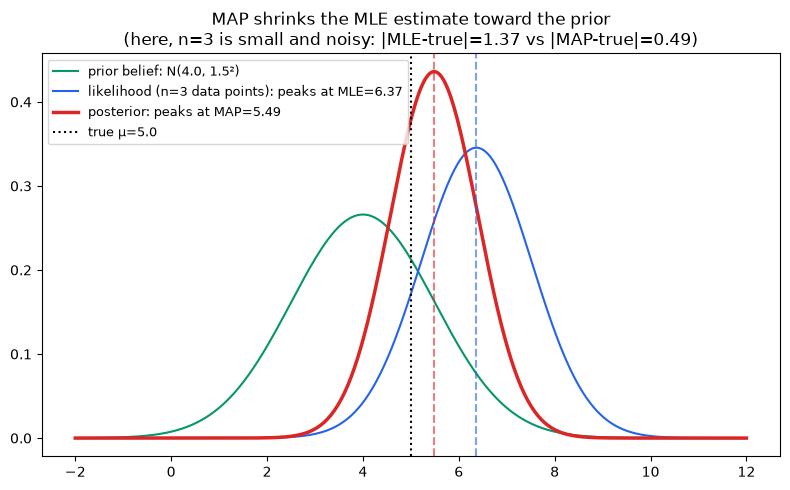

In [4]:
def visualize_map_vs_mle(savepath: Path = None):
    true_mu = 5.0
    sigma = 2.0
    # Hand-picked small sample (n=3) whose mean is noisy/off from the true mean --
    # exactly the small-sample regime where a reasonable prior helps most.
    data = np.array([7.8, 6.5, 4.8])
    n = len(data)
    mle_mu = data.mean()

    mu0, tau0 = 4.0, 1.5   # a "reasonable" prior belief -- not exactly right, not wildly wrong

    posterior_var = 1 / (1/tau0**2 + n/sigma**2)
    posterior_mu = posterior_var * (mu0/tau0**2 + n*mle_mu/sigma**2)

    x = np.linspace(-2, 12, 400)
    prior_pdf = (1/(tau0*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu0)/tau0)**2)
    like_std = sigma/np.sqrt(n)
    like_pdf = (1/(like_std*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mle_mu)/like_std)**2)
    post_std = np.sqrt(posterior_var)
    post_pdf = (1/(post_std*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-posterior_mu)/post_std)**2)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, prior_pdf, color="#059669", label=f"prior belief: N({mu0}, {tau0}²)")
    ax.plot(x, like_pdf, color="#2563eb", label=f"likelihood (n={n} data points): peaks at MLE={mle_mu:.2f}")
    ax.plot(x, post_pdf, color="#dc2626", linewidth=2.5, label=f"posterior: peaks at MAP={posterior_mu:.2f}")
    ax.axvline(true_mu, color="black", linestyle=":", label=f"true μ={true_mu}")
    ax.axvline(mle_mu, color="#2563eb", linestyle="--", alpha=0.6)
    ax.axvline(posterior_mu, color="#dc2626", linestyle="--", alpha=0.6)
    ax.legend(fontsize=9)
    ax.set_title(f"MAP shrinks the MLE estimate toward the prior\n"
                 f"(here, n={n} is small and noisy: |MLE-true|={abs(mle_mu-true_mu):.2f} vs |MAP-true|={abs(posterior_mu-true_mu):.2f})")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()
    return mle_mu, posterior_mu

mle_mu, map_mu = visualize_map_vs_mle(FIG_DIR / "map_vs_mle.png")

Notice the posterior (red) sits **between** the prior (green) and the likelihood (blue) — pulled toward the prior, but not all the way. That pull is called **shrinkage**. In this particular small sample, the raw MLE happened to land noisily far from the true value, and the reasonable prior pulled the estimate back closer — but that's a property of *this* sample, not a guarantee for every single draw. What shrinkage reliably does, on average across many samples, is **trade a small amount of bias for a meaningful reduction in variance** — which is often a net win, especially with little data. That trade-off is exactly the bias-variance tradeoff covered in the next notebook.

**The regularization connection, made explicit:** take logs of `posterior ∝ likelihood × prior`:

```
log posterior = log likelihood + log prior
```

With Gaussian noise, `-log likelihood` gives you the familiar MSE term. With a Gaussian prior `N(0, τ²)` on the weights `w`, `-log prior = (1/2τ²)‖w‖² + const`. So **maximizing the posterior is exactly minimizing `MSE + λ‖w‖²`**, where `λ = σ²/τ²` — the ridge regression objective. Ridge regression isn't just "add a penalty term that happens to work" — it's the direct consequence of doing MAP estimation with a Gaussian prior on the weights. (A Laplace prior on the weights, by the same logic, gives you Lasso's L1 penalty instead.)

---

## Self-check before moving on

- [ ] I can explain, using the CLT, why the Gaussian shows up as a default assumption so often
- [ ] I can state what MLE optimizes for, in one sentence
- [ ] I can explain MAP as "MLE plus a prior" and describe the shrinkage effect
- [ ] I can derive why MAP with a Gaussian prior is equivalent to L2/ridge regularization, from `log posterior = log likelihood + log prior`
- [ ] I know which prior corresponds to L1/Lasso regularization

Next: `03-hypothesis-testing-bias-variance.ipynb`